# Primary Care Access Activity Signal - Nova Scotia

This notebook processes the Nova Scotia Open Data dataset **“Accessing Primary Care in Nova Scotia”** to create a clean monthly time series of primary care access activity by health zone.

## Purpose
Alternative primary care delivery channels (clinics, pharmacies, mobile clinics, virtual care, urgent treatment centres) expand when attachment gaps exist.  
Monthly visit volumes across these channels serve as a leading indicator of upstream primary care demand and health system pressure

## Output
This notebook produces a processed dataset:

`data_processed/primary_care_access_activity_ns.csv`

containing:

- Zone
- Date (monthly)
- primary_care_visits
- visits_roll3 (3-month rolling mean)
- visits_pct_change (monthly % change)

This dataset will later be merged with EMS and hospital indicators to model system pressure relationships.

## Data Source

Nova Scotia Open Data — *Accessing Primary Care in Nova Scotia*

This dataset reports monthly activity across alternative primary care delivery channels, including primary care clinics, community pharmacies, mobile clinics, virtual care, and urgent treatment centres.  
Data are aggregated and anonymized by Nova Scotia Health zone.

In [1]:
import os
os.getcwd()

'c:\\ns-health-signals\\notebooks'

## Load Raw Dataset
Load the Nova Scotia Open Data primary care access dataset and inspect structure.

In [19]:
import os
os.listdir("../data_raw")

['primary_care_access_ns_20260223.csv']

In [20]:
import pandas as pd

df = pd.read_csv("../data_raw/primary_care_access_ns_20260223.csv")
df.head()

,Zone,Hospital,Type,Date,Measure Name,Actual,CTAS
0,Northern,NaN,Primary Care Clinics,2023-12-01,Nova Scotians on the NAFP Registry are eligibl...,"24,106",NaN
1,Western,NaN,Community Pharmacy PCCs,2023-12-01,Visits were completed at Community Pharmacy Pr...,"2,918",NaN
2,Western,NaN,UCC,2023-12-01,Visits were completed at Urgent Care Centres,567,NaN
3,Western,NaN,Primary Care Clinics,2023-12-01,Nova Scotians on the NAFP Registry are eligibl...,"26,124",NaN
4,Central,NaN,Mobile Primary Care,2023-12-01,Visits were completed at Mobile Primary Care C...,"1,297",NaN


## Explore Measures
Identify which indicators represent completed primary care visits across access channels.

In [4]:
df.columns
df["Measure Name"].value_counts().head(30)

Measure Name
Visits were completed at Primary Care Clinics                                                  145
Primary care services were completed at Community Pharmacies                                    84
Nova Scotians on the NAFP Registry are eligible to access care through Primary Care Clinics     84
Visits were completed at Urgent Treatment Centres                                               74
Visits were completed at Pharmacy+ Clinics                                                      53
Visits were completed at Mobile Primary Care Clinics                                            51
Visits were completed at Diabetes Centres                                                       45
Visits were completed at Community Pharmacy Primary Care Clinics                                40
Visits were completed at Urgent Care Centres                                                    31
Visits were completed through VirtualCareNS                                                     

## Select Visit-Based Access Measures
Filter dataset to include only measures representing completed visits at primary care access channels.

In [5]:
keep_measures = [
"Visits were completed at Primary Care Clinics",
"Primary care services were completed at Community Pharmacies",
"Visits were completed at Mobile Primary Care Clinics",
"Visits were completed at Community Pharmacy Primary Care Clinics",
"Visits were completed through VirtualCareNS",
"Visits were completed at Pharmacy+ Clinics",
"Visits were completed at Urgent Treatment Centres",
"Visits were completed at Urgent Care Centres"
]

df_access = df[df["Measure Name"].isin(keep_measures)].copy()

df_access.shape

(509, 7)

## Clean Numeric and Date Fields
Convert visit counts from text with commas to numeric values and parse Date as datetime.

In [6]:
df_access[["Zone","Hospital","Date","Measure Name","Actual"]].head()

,Zone,Hospital,Date,Measure Name,Actual
1,Western,NaN,2023-12-01,Visits were completed at Community Pharmacy Pr...,"2,918"
2,Western,NaN,2023-12-01,Visits were completed at Urgent Care Centres,567
4,Central,NaN,2023-12-01,Visits were completed at Mobile Primary Care C...,"1,297"
5,Central,NaN,2023-12-01,Visits were completed at Community Pharmacy Pr...,"5,050"
6,Eastern,NaN,2023-12-01,Visits were completed at Primary Care Clinics,"1,520"


In [7]:
df_access["Actual"] = (
    df_access["Actual"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [8]:
df_access["Date"] = pd.to_datetime(df_access["Date"])

## Indicator Definition — Primary Care Access Activity

**primary_care_visits** is defined as the total number of *completed visits* per month across selected access channels (clinics, pharmacies, mobile clinics, VirtualCareNS, urgent centres), aggregated by Nova Scotia Health Zone.

In [9]:
access_monthly = (
    df_access
    .groupby(["Zone","Date"], as_index=False)["Actual"]
    .sum()
    .rename(columns={"Actual":"primary_care_visits"})
)

access_monthly.head()

,Zone,Date,primary_care_visits
0,Central,2020-12-01,589.0
1,Central,2021-01-01,363.0
2,Central,2021-02-01,559.0
3,Central,2021-03-01,823.0
4,Central,2021-04-01,926.0


In [10]:
access_monthly.groupby("Zone")["primary_care_visits"].describe()

,count,mean,std,min,25%,50%,75%,max
Zone,,,,,,,,
Central,33.0,9121.242424,7344.443618,1.0,684.0,10594.0,14253.0,21105.0
Eastern,37.0,5232.729730,4351.524520,208.0,422.0,6194.0,8123.0,12463.0
Northern,39.0,5171.666667,4284.478826,2.0,777.5,7073.0,8219.5,11760.0
Unknown,31.0,3635.806452,2554.616128,36.0,1922.5,3165.0,5725.0,10399.0
Western,37.0,5521.891892,4387.598899,102.0,1182.0,5916.0,9352.0,12893.0


In [12]:
access_monthly = access_monthly[access_monthly["Zone"] != "Unknown"].copy()

In [13]:
access_monthly["Zone"].unique()

array(['Central', 'Eastern', 'Northern', 'Western'], dtype=object)

## Preliminary Interpretation

Primary care access activity increases over time across all Nova Scotia health zones, consistent with expansion of alternative access programs.  
Central zone shows the highest absolute volumes, reflecting population distribution and service concentration.

These trends support the use of alternative primary care activity as an upstream indicator of system access dynamics.  
The processed dataset will be integrated with EMS and hospital indicators in subsequent analysis.

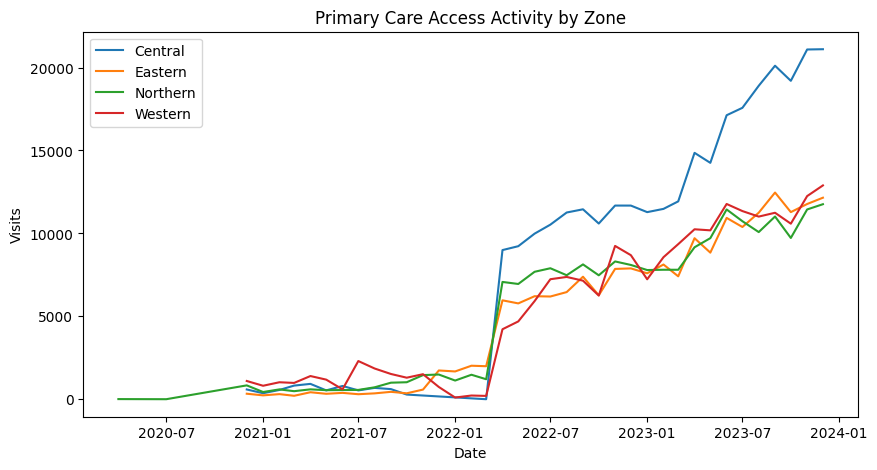

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for zone in access_monthly["Zone"].unique():
    subset = access_monthly[access_monthly["Zone"] == zone]
    plt.plot(subset["Date"], subset["primary_care_visits"], label=zone)

plt.legend()
plt.title("Primary Care Access Activity by Zone")
plt.xlabel("Date")
plt.ylabel("Visits")
plt.show()

In [14]:
access_monthly = access_monthly.sort_values(["Zone","Date"])

access_monthly["visits_roll3"] = (
    access_monthly
    .groupby("Zone")["primary_care_visits"]
    .transform(lambda x: x.rolling(3, min_periods=1).mean())
)

In [15]:
access_monthly["visits_pct_change"] = (
    access_monthly
    .groupby("Zone")["primary_care_visits"]
    .pct_change()
)

In [16]:
access_monthly.to_csv(
    "../data_processed/primary_care_access_activity_ns.csv",
    index=False
)

## Assumptions and Limitations

- Visit counts represent completed encounters, not unique patients.
- Alternative access channels are used as a proxy for primary care attachment gaps and access pressure.
- “Unknown” zone records were excluded to maintain geographic consistency.
- Early months show lower volumes due to phased implementation of access programs.
- Data are aggregated monthly and do not capture intra-month variability.
- This is an activity proxy and may reflect program expansion, reporting changes, or access substitution—not only unmet need.